# Control Systems Simulator (CSSIM)

Maurício Shoji Sugahara Pires

Orientador: Prof. Markus Vinícius Santos Lima

Departamento de Engenharia Elétrica - UFRJ

## Sistemas de primeira ordem

<center>
<img src="img/first_order.png" alt="Sistema de primeira ordem" width="60%">
</center>

Considerando o sistema de primeira ordem mostrado acima, a relação entrada-saída é dada por:

\begin{equation}
\frac{C(s)}{R(s)} = \frac{1}{T s + 1}.
\tag{1.1}
\end{equation}

A seguir analisaremos as respostas do sistema a entradas com funções degrau unitário e rampa unitária, considerando condições iniciais nulas.

### Resposta ao degrau unitário

Como a transformada de Laplace da função degrau unitário é $\frac{1}{s}$.
Substituindo $R(s) = \frac{1}{s}$ na Equação 1.1, obtemos:

\begin{equation}
C(s) = \frac{1}{Ts + 1}\,\frac{1}{s}
\end{equation}

Expandindo $C(s)$ em frações parciais, temos:

\begin{equation}
C(s) = \frac{1}{s} - \frac{T}{Ts + 1}
       = \frac{1}{s} - \frac{1}{s + (1/T)}
\tag{1.2}
\end{equation}

Considerando a transformada inversa de Laplace da Equação 1.2, obtemos:

\begin{equation}
c(t) = 1 - e^{-t/T}, \quad \text{para } t \ge 0
\tag{1.3}
\end{equation}

De acordo com a Equação 1.3, a resposta $c(t)$ é inicialmente zero e, no fim,
torna-se unitária.
Quanto menor a constante de tempo $T$, mais rapidamente o sistema
responde.

### Passo a passo do fluxo de simulação

A seguir, o arquivo `diagrams/first_order_step.json` é analisado no mesmo fluxo usado pelo simulador:

$$
E(s)=R(s)-C(s), \qquad \frac{C(s)}{R(s)}=\frac{1}{Ts+1}.
$$

O passo a passo será organizado em 10 etapas:

1. Leitura do diagrama em JSON.
2. Criação do grafo do diagrama.
3. Resolução dos parâmetros simbólicos.
4. Categorização dos blocos.
5. Conversão da função de transferência para espaço de estados.
6. Montagem do modelo matemático do sistema.
7. Geração dos sinais de entrada.
8. Execução da simulação.
9. Visualização dos resultados.
10. Incorporação ao Jupyter Notebook.

In [1]:
from pprint import pprint
import inspect
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math

from cssim import (
    load_json,
    build_graph,
    set_parameters,
    resolve_param,
    categorize_blocks,
    tf_to_ss,
    build_solver,
    compute_rhs,
    generate_input_signal,
    run_simulation,
    plot_signals,
    open_gui,
)

s = sp.Symbol("s")
diagram_path = "diagrams/first_order_step.json"
T = 1
param_values = {"T": T}
set_parameters(param_values)

data = load_json(diagram_path)
display(Markdown("#### Contexto comum para as etapas"))
print("diagram_path =", diagram_path)
print("param_values =", param_values)
print("Tipo de data =", type(data).__name__)

#### Contexto comum para as etapas

diagram_path = diagrams/first_order_step.json
param_values = {'T': 1}
Tipo de data = dict


#### 1. Leitura do diagrama em JSON

Função usada: `load_json(diagram_path)`.

**Entrada**

- `diagram_path`: caminho do arquivo JSON.

**Saída**

- `data`: dicionário com `blocks`, `connections`, `sim_time` e `step_size`.

Nesse arquivo, os blocos representam a entrada, o somador, a função de transferência e a saída.

$$
R(s)=\frac{1}{s}, \qquad E(s)=R(s)-C(s), \qquad G(s)=\frac{1}{Ts}, \qquad C(s)=G(s)E(s).
$$

In [3]:
input_block = next(b for b in data["blocks"] if b["type"] == "input")
operation_block = next(b for b in data["blocks"] if b["type"] == "operation")
tf_block = next(b for b in data["blocks"] if b["type"] == "transfer_function")
output_block = next(b for b in data["blocks"] if b["type"] == "output")

print("Entrada de load_json():", diagram_path)
print("Saída de load_json(): data")
print("Chaves principais =", list(data.keys()))
print("Número de blocos =", len(data["blocks"]))
print("Número de conexões =", len(data["connections"]))

pprint(
    {
        "input": input_block["attributes"],
        "operation": operation_block["attributes"],
        "transfer_function": tf_block["attributes"],
        "output": output_block["attributes"],
    }
)

display(Math(r"R(s)=\frac{1}{s}"))
display(Math(r"E(s)=R(s)-C(s)"))
display(Math(r"G(s)=\frac{1}{Ts}"))
display(Math(r"C(s)=G(s)E(s)"))

Entrada de load_json(): diagrams/first_order_step.json
Saída de load_json(): data
Chaves principais = ['blocks', 'connections', 'sim_time', 'step_size']
Número de blocos = 4
Número de conexões = 5
{'input': {'data-a': '1',
           'data-a0': '0',
           'data-f': '',
           'data-m': '',
           'data-name': 'Entrada',
           'data-offset': '',
           'data-phase': '',
           'data-signal': 'step',
           'data-t0': '0'},
 'operation': {'data-name': '',
               'data-operator-1': '+',
               'data-operator-2': '-',
               'data-position': 'bottom'},
 'output': {'data-name': 'Saída'},
 'transfer_function': {'data-denominator': 'T*s',
                       'data-name': 'Função de transferência',
                       'data-numerator': '1'}}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### 2. Criação do grafo do diagrama

Função usada: `build_graph(data)`.

**Entrada**

- `data`: estrutura lida do JSON.

**Saída**

- `G`: grafo direcionado com blocos como nós e fluxos de sinal como arestas.

No grafo, a estrutura física do diagrama é convertida em uma estrutura computacional.

In [4]:
G = build_graph(data)

block_types = {block["id"]: block["type"] for block in data["blocks"]}

print("Entrada de build_graph(): data")
print("Saída de build_graph(): G")
print("Nós do grafo:", list(G.nodes))
print("Tipo de bloco:")
for node in G.nodes:
    print(f"  {node}: {block_types.get(node)}")
print("Arestas do grafo:")
for u, v, attrs in G.edges(data=True):
    print(f"  {u} -> {v}  position={attrs.get('position')}")


Entrada de build_graph(): data
Saída de build_graph(): G
Nós do grafo: ['Block0', 'Block1', 'Block2', 'Block3']
Tipo de bloco:
  Block0: input
  Block1: operation
  Block2: transfer_function
  Block3: output
Arestas do grafo:
  Block0 -> Block1  position=left
  Block1 -> Block2  position=left
  Block2 -> Block3  position=left
  Block2 -> Block1  position=bottom


#### 3. Resolução dos parâmetros simbólicos

Função usada: `resolve_param(expr, allow_s=False, default=None)`.

**Entrada**

- expressões simbólicas do diagrama, como `"T"`.

**Saída**

- valores numéricos usados pelo simulador.

Neste exemplo, o parâmetro simbólico é a constante de tempo $T$. Ao resolver esse parâmetro, a representação simbólica do bloco

$$
G(s)=\frac{1}{Ts}
$$

passa a usar o valor numérico definido no notebook.

In [5]:
T_expr = "T"
T_value = resolve_param(T_expr, default=None)
num_expr = tf_block["attributes"]["data-numerator"]
den_expr = tf_block["attributes"]["data-denominator"]
num_sym = sp.sympify(num_expr, locals={"s": s})
den_sym = sp.sympify(den_expr, locals={"T": T_value, "s": s})

print("Entrada de resolve_param():", T_expr)
print("Saída de resolve_param():", T_value)
print("Numerador simbólico =", num_expr)
print("Denominador simbólico =", den_expr)
print("Denominador com parâmetro resolvido =", den_sym)

display(Math(r"T=%s" % sp.latex(T_value)))
display(Math(r"G(s)=\frac{%s}{%s}" % (sp.latex(num_sym), sp.latex(den_sym))))

Entrada de resolve_param(): T
Saída de resolve_param(): 1.0
Numerador simbólico = 1
Denominador simbólico = T*s
Denominador com parâmetro resolvido = 1.0*s


<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### 4. Categorização dos blocos

Função usada: `categorize_blocks(data, G, param_values)`.

**Entrada**

- `data`: diagrama em JSON.
- `G`: grafo do diagrama.
- `param_values`: parâmetros já resolvidos, aqui `{"T": T}`.

**Saída**

- `input_blocks`, `tf_blocks`, `static_blocks`, `pid_blocks`, `output_blocks` e `total_states`.

Nessa etapa, cada bloco do diagrama recebe um papel no modelo matemático:

- o bloco de entrada representa $r(t)$ e $R(s)$;
- o somador representa $e(t)=r(t)-c(t)$;
- o bloco dinâmico representa $G(s)=\frac{1}{Ts}$;
- o bloco de saída representa $c(t)$ e $C(s)$.

In [7]:
(
    input_blocks,
    tf_blocks,
    static_blocks,
    pid_blocks,
    output_blocks,
    total_states,
) = categorize_blocks(data, G, param_values=param_values)

print("categorize_blocks(data, G, param_values)")
print("input_blocks =", input_blocks)
print("tf_blocks =", [block["id"] for block in tf_blocks])
print("static_blocks =", [block["id"] for block in static_blocks])
print("pid_blocks =", pid_blocks)
print("output_blocks =", output_blocks)
print("total_states =", total_states)

categorize_blocks(data, G, param_values)
input_blocks = ['Block0']
tf_blocks = ['Block2']
static_blocks = ['Block1']
pid_blocks = []
output_blocks = ['Block3']
total_states = 1


#### 5. Conversão da função de transferência para espaço de estados

Função usada: `tf_to_ss(num, den, verbose=False, param_values=None)`.

**Entrada**

- `num = "1"`
- `den = "T*s"`
- `param_values = {"T": T}`

**Saída**

- matrizes `A`, `B`, `C`, `D` do bloco dinâmico.

Para a função de transferência

$$
G(s)=\frac{C(s)}{E(s)}=\frac{1}{Ts},
$$

a representação em espaço de estados pode ser escrita como

$$
\dot{x}(t)=A x(t)+B e(t), \qquad c(t)=C x(t)+D e(t).
$$

In [8]:
A_tf, B_tf, C_tf, D_tf = tf_to_ss(
    tf_block["attributes"]["data-numerator"],
    tf_block["attributes"]["data-denominator"],
    param_values=param_values,
)

tf_info = tf_blocks[0]

print("Entrada de tf_to_ss():", tf_block["attributes"]["data-numerator"], "/", tf_block["attributes"]["data-denominator"])
print("A =\n", A_tf)
print("B =\n", B_tf)
print("C =\n", C_tf)
print("D =", D_tf)
# print("state_slice =", tf_info["state_slice"])


Entrada de tf_to_ss(): 1 / T*s
A =
 [[-0.]]
B =
 [[1.]]
C =
 [[1.]]
D = 0.0


#### 6. Montagem do modelo matemático do sistema

Funções usadas: `build_solver(...)` e `compute_rhs(...)`.

**Entrada de `build_solver(...)`**

- `input_blocks`, `static_blocks`, `tf_blocks`, `pid_blocks`, `total_states`.

**Saída de `build_solver(...)`**

- `output_ids`, `output_index`, `M_inv`, `input_map`, `C_matrix`.

**Entrada de `compute_rhs(...)`**

- sinais de entrada, bloco dinâmico e estruturas algébricas do sistema.

**Saída de `compute_rhs(...)`**

- `rhs(t, x)`, a dinâmica do sistema para integração numérica.

Com a nomenclatura da Cell 1, o modelo fica:

$$
e(t)=r(t)-c(t), \qquad c(t)=\frac{1}{T}x(t),
$$

logo

$$
\dot{x}(t)=r(t)-\frac{1}{T}x(t).
$$

Equivalentemente,

$$
T\dot{c}(t)+c(t)=r(t)
\qquad\Longleftrightarrow\qquad
\frac{C(s)}{R(s)}=\frac{1}{Ts+1}.
$$

In [15]:
output_ids, output_index, M_inv, input_map, C_matrix = build_solver(
    input_blocks, static_blocks, tf_blocks, pid_blocks, total_states
)

rhs = compute_rhs(
    generate_input_signal(data),
    tf_blocks,
    pid_blocks,
    output_ids,
    output_index,
    M_inv,
    input_map,
    C_matrix,
)

x0 = np.zeros(total_states)
x_test = np.array([0.4])

print("build_solver(input_blocks, static_blocks, tf_blocks, pid_blocks, total_states)")
print("output_ids =", output_ids)
print("output_index =", output_index)
print("M_inv =\n", M_inv)
print("input_map =", input_map)
print("C_matrix =\n", C_matrix)
print("compute_rhs(input_signals, tf_blocks, pid_blocks, output_ids, output_index, M_inv, input_map, C_matrix)")
print("rhs(0.0, x0) =", rhs(0.0, x0))
print("rhs(0.5, x_test) =", rhs(0.5, x_test))

build_solver(input_blocks, static_blocks, tf_blocks, pid_blocks, total_states)
output_ids = ['Block1', 'Block2']
output_index = {'Block1': 0, 'Block2': 1}
M_inv =
 [[ 1. -1.]
 [ 0.  1.]]
input_map = {0: [('Block0', 1.0)], 1: []}
C_matrix =
 [[0.]
 [1.]]
compute_rhs(input_signals, tf_blocks, pid_blocks, output_ids, output_index, M_inv, input_map, C_matrix)
rhs(0.0, x0) = [1.]
rhs(0.5, x_test) = [0.6]


#### 7. Geração dos sinais de entrada

Função usada: `generate_input_signal(data)`.

**Entrada**

- `data`: diagrama contendo os atributos do bloco de entrada.

**Saída**

- `input_signal_funcs`: dicionário de funções temporais.

Para este diagrama, o bloco de entrada gera um degrau unitário:

$$
r(t)=u(t)
\qquad\Longleftrightarrow\qquad
R(s)=\frac{1}{s}.
$$

In [10]:
input_signal_funcs = generate_input_signal(data)
r = input_signal_funcs[input_blocks[0]]

print("Entrada de generate_input_signal(): data")
print("Saída input_signal_funcs =", list(input_signal_funcs.keys()))
print("r(0.0) =", r(0.0))
print("r(1.0) =", r(1.0))
print("r(2.0) =", r(2.0))

display(Math(r"r(t)=u(t)"))

Entrada de generate_input_signal(): data
Saída input_signal_funcs = ['Block0']
r(0.0) = 1.0
r(1.0) = 1.0
r(2.0) = 1.0


<IPython.core.display.Math object>

#### 8. Execução da simulação

Função usada: `run_simulation(data, step_size, simulation_time, param_values)`.

**Entrada**

- `data`
- `step_size = data["step_size"]`
- `simulation_time = data["sim_time"]`
- `param_values = {"T": T}`

**Saída**

- `t`, `input_signal_funcs_sim`, `input_blocks_sim`, `output_out`.

Após integrar a dinâmica do sistema, a saída calculada deve reproduzir a resposta da Cell 1:

$$
c(t)=1-e^{-t/T}, \quad t \ge 0.
$$

In [12]:
t, input_signal_funcs_sim, input_blocks_sim, output_out = run_simulation(
    data,
    step_size=data["step_size"],
    simulation_time=data["sim_time"],
    param_values=param_values,
)

c_sim = output_out[output_blocks[0]]
c_analytic = 1 - np.exp(-t / T)
max_error = np.max(np.abs(c_sim - c_analytic))

print("run_simulation(data, step_size, simulation_time, param_values)")
print("len(t) =", len(t))
print("input_blocks_sim =", input_blocks_sim)
print("output_out.keys() =", list(output_out.keys()))
print("c_sim[0:5] =", c_sim[:5])
print("c_analytic[0:5] =", c_analytic[:5])
print("Erro máximo =", max_error)

run_simulation(data, step_size, simulation_time, param_values)
len(t) = 10000
input_blocks_sim = ['Block0']
output_out.keys() = ['Block3']
c_sim[0:5] = [0.         0.0009995  0.001998   0.0029955  0.00399201]
c_analytic[0:5] = [0.         0.0009995  0.001998   0.0029955  0.00399201]
Erro máximo = 0.00014044069012331128


#### 9. Visualização dos resultados

Função usada: `plot_signals(t, input_signals, input_blocks, outputs, data_diagram)`.

**Entrada**

- `t`
- `input_signal_funcs_sim`
- `input_blocks_sim`
- `output_out`
- `data`

**Saída**

- gráfico com os sinais de entrada e saída.

Nessa visualização, aparecem simultaneamente:

$$
r(t)=u(t)
$$

e

$$
c(t)=1-e^{-t/T}.
$$

Entrada de plot_signals(): t, input_signal_funcs_sim, input_blocks_sim, output_out, data
Saída de plot_signals(): figura com r(t) e c(t)


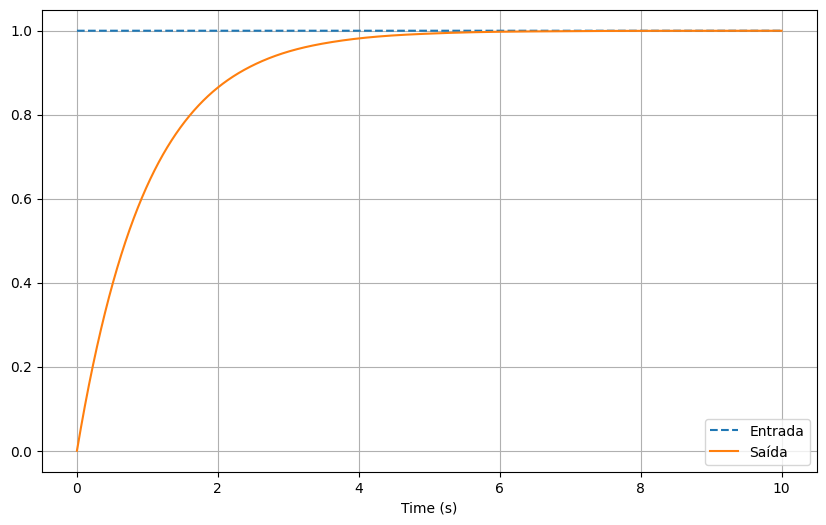

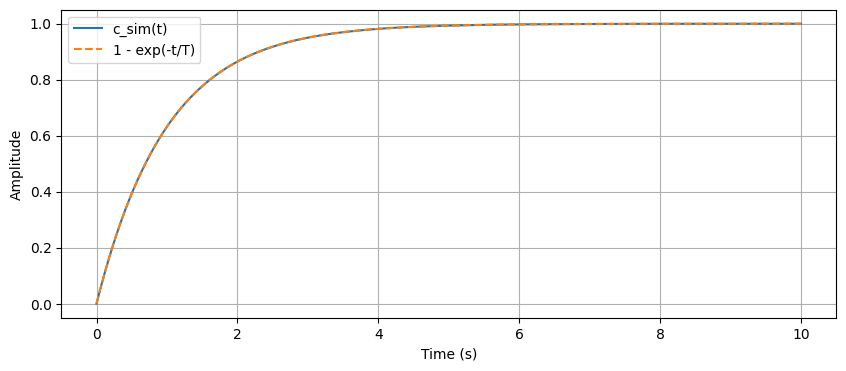

In [13]:
print("Entrada de plot_signals(): t, input_signal_funcs_sim, input_blocks_sim, output_out, data")
print("Saída de plot_signals(): figura com r(t) e c(t)")
plot_signals(t, input_signal_funcs_sim, input_blocks_sim, output_out, data)

plt.figure(figsize=(10, 4))
plt.plot(t, c_sim, label="c_sim(t)")
plt.plot(t, c_analytic, "--", label="1 - exp(-t/T)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

#### 10. Incorporação ao Jupyter Notebook

Função usada: `open_gui(diagram_path=None, port=8000, width="100%", height=700)`.

In [14]:
%matplotlib widget
from cssim import open_gui
open_gui("diagrams/first_order_step.json")

T = 1